In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#!pip install emcee
#!pip install corner

In [3]:
import emcee
import corner

### 1) Load and Plot data

In [4]:
data = np.load(r'C:\Users\utente\astrostatistics_bicocca_2026\solutions\transient.npy')

In [5]:
time = data[:,0]
flux = data[:,1]
sigma = data[:,2]

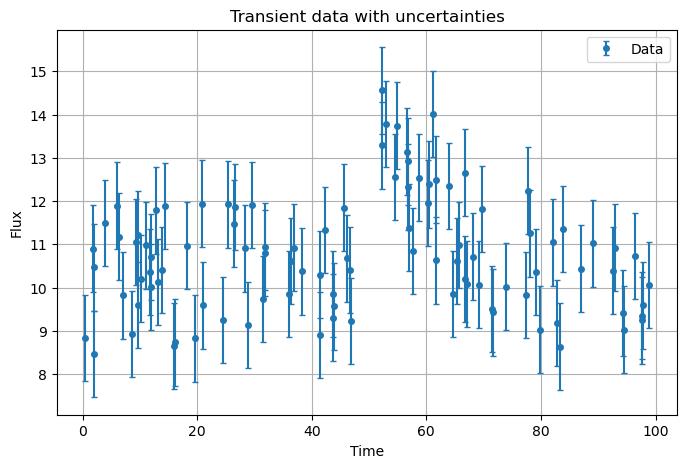

In [6]:
plt.figure(figsize=(8,5))
plt.errorbar(time, flux, yerr=sigma, fmt='o', ms=4, capsize=2, label='Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Transient data with uncertainties')
plt.legend()
plt.grid(True)
plt.show()

### 2) Define the model and the likelihood

In [37]:
def burst_model(time, b, A, t0, alpha):
    model = np.full_like(time, b)
    mask = time >= t0
    dt = time[mask] - t0

    exponent = -alpha*dt
    exponent = np.clip(exponent, -700, 700)

    model[mask] = b + A*np.exp(exponent)
    return model

In [8]:
def log_prior(theta):
    b, A, t0, ln_alpha = theta

    if (0<b<50 and 0<A<50 and 0<t0<100 and -5<ln_alpha<5):
        return 0.0

    return -np.inf

In [9]:
def log_likelihood(theta, time, flux, sigma):
    b, A, t0, ln_alpha = theta
    alpha = np.exp(ln_alpha)

    model = burst_model(time, b, A, t0, alpha)

    return -0.5 * np.sum(((flux - model)/sigma)**2 + np.log(2*np.pi*sigma**2))

In [10]:
def log_posterior(theta, time, flux, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, time, flux, sigma)

### 3) Run MCMC


In [11]:
ndim = 4
nwalkers = 32
nsteps = 10000
burnin = 1000

In [12]:
initial = np.array([10, 20, 50, np.log(0.1)])
pos = initial + 1e-2*np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(time, flux, sigma))
print('Running MCMC...')
sampler.run_mcmc(pos, nsteps, progress=True);

Running MCMC...


  0%|                                                                                        | 0/10000 [00:00<?, ?it/s]C:\Users\utente\AppData\Local\Temp\ipykernel_3480\439351690.py:2: RuntimeWarning: overflow encountered in exp
  model = np.where(time<t0, b, b+A*np.exp(-alpha*(time-t0)))
  0%|▍                                                                             | 50/10000 [00:00<00:19, 499.83it/s]C:\Users\utente\AppData\Local\Temp\ipykernel_3480\439351690.py:2: RuntimeWarning: overflow encountered in multiply
  model = np.where(time<t0, b, b+A*np.exp(-alpha*(time-t0)))
100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:38<00:00, 257.26it/s]


In [13]:
samples = sampler.get_chain()
flat_samples = sampler.get_chain(discard=burnin, thin=10, flat=True)

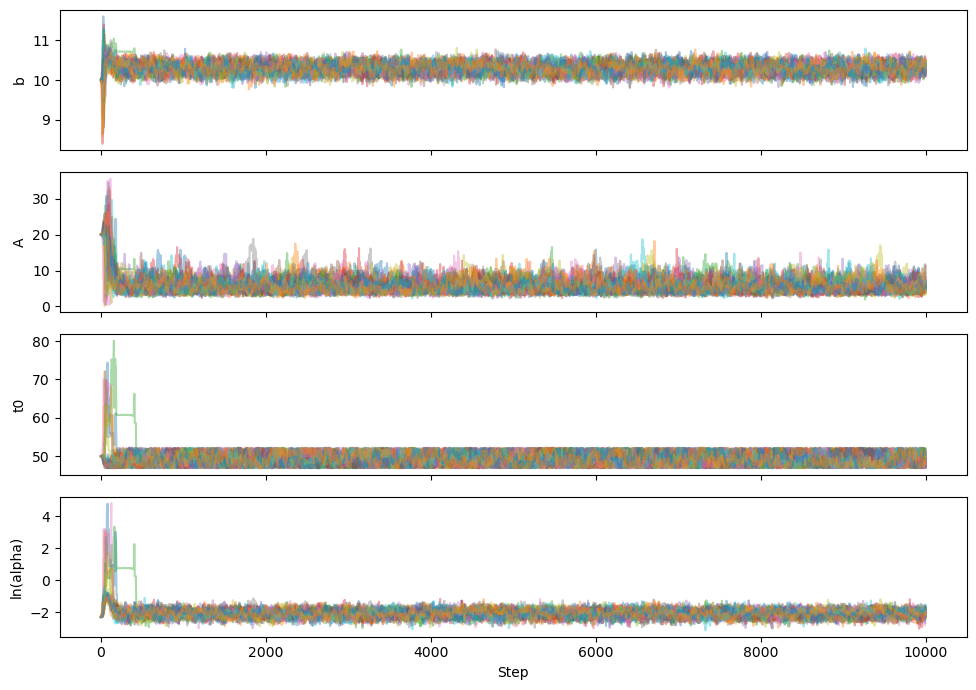

In [14]:
labels = ['b', 'A', 't0', 'ln(alpha)']
fig, axes = plt.subplots(ndim, figsize=(10,7), sharex=True)

for i in range(ndim):
    axes[i].plot(samples[:,:,i], alpha=0.4)
    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel('Step')
plt.tight_layout()
plt.show()

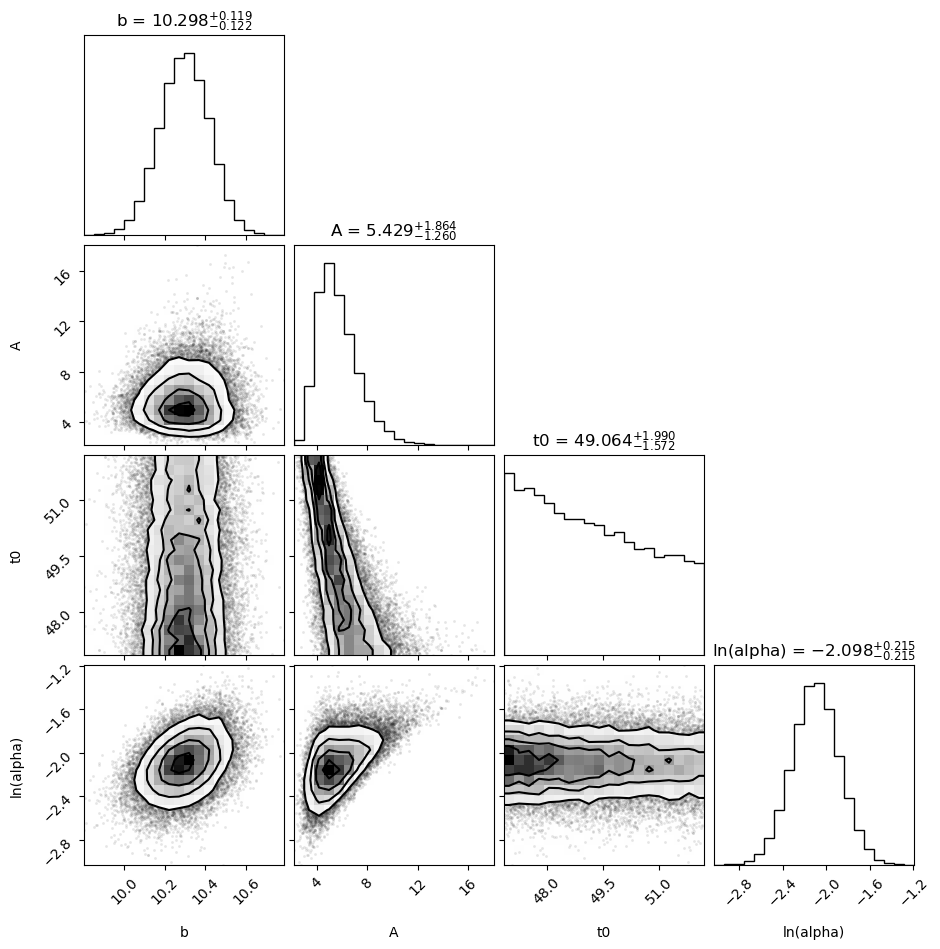

In [15]:
corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f"
)
plt.show()

In [16]:
for i, label in enumerate(labels):
    q16, q50, q84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{label} = {q50:.3f} (+{q84-q50:.3f}, -{q50-q16:.3f})")

alpha_samples = np.exp(flat_samples[:, 3])
q16, q50, q84 = np.percentile(alpha_samples, [16,50,84])
print(f"\nalpha = {q50:.5f} (+{q84-q50:.5f}, -{q50-q16:.5f})")

b = 10.298 (+0.119, -0.122)
A = 5.429 (+1.864, -1.260)
t0 = 49.064 (+1.990, -1.572)
ln(alpha) = -2.098 (+0.215, -0.215)

alpha = 0.12275 (+0.02939, -0.02375)


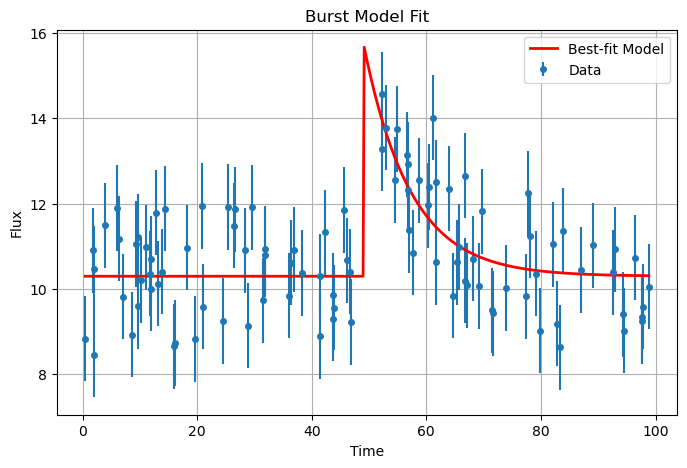

In [17]:
b_med  = np.median(flat_samples[:,0])
A_med  = np.median(flat_samples[:,1])
t0_med = np.median(flat_samples[:,2])
a_med  = np.exp(np.median(flat_samples[:,3]))

tt = np.linspace(time.min(), time.max(), 500)
yy = burst_model(tt, b_med, A_med, t0_med, a_med)

plt.figure(figsize=(8,5))
plt.errorbar(time, flux, yerr=sigma, fmt='o', ms=4, label="Data")
plt.plot(tt, yy, 'r-', lw=2, label="Best-fit Model")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Burst Model Fit")
plt.legend()
plt.grid(True)
plt.show()

### 4) Burn-in

In [18]:
tau = sampler.get_autocorr_time(tol=0)
print(tau)

[ 54.7524897  111.76222434  80.8164326   84.70718023]


In [19]:
tau_max = int(np.max(tau))

burnin = int(2*tau_max)
thin = int(0.5*tau_max)

print(f'burn-in = {burnin}, thinning = {thin}')

burn-in = 222, thinning = 55


In [20]:
flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)

In [21]:
print(flat_samples.shape)

(5664, 4)


### 5) Corner plot

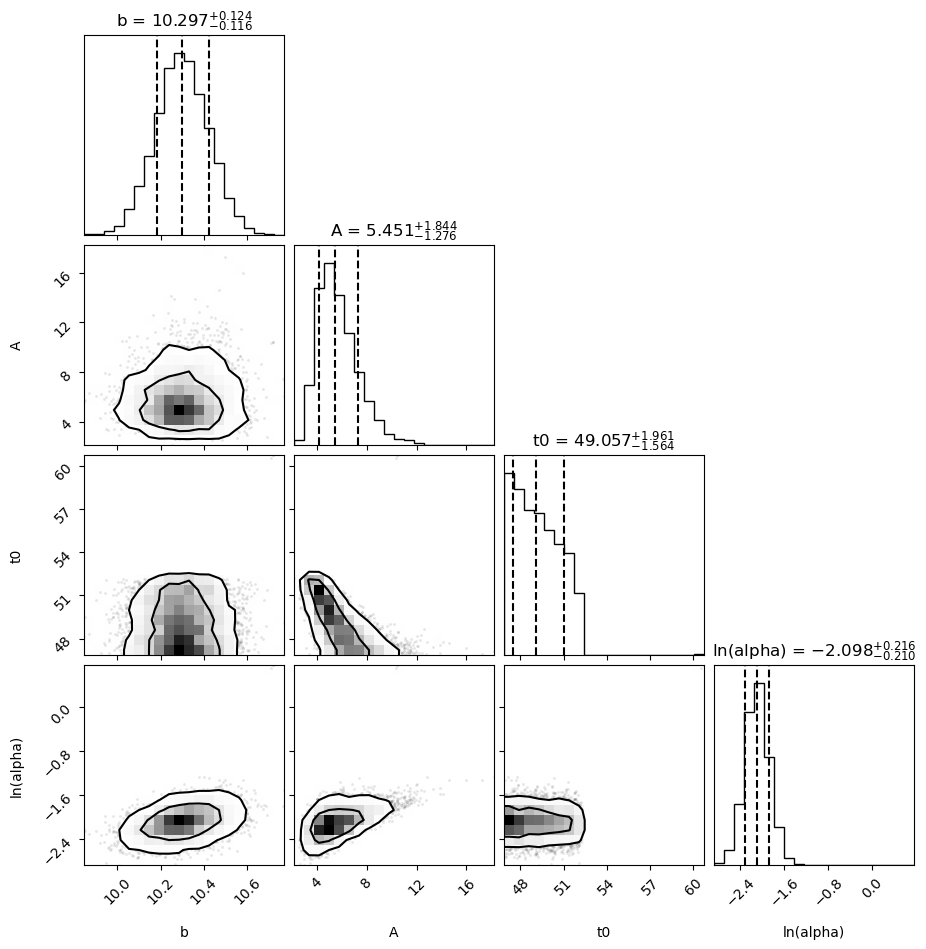

In [22]:
fig = corner.corner(
    flat_samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95],
    show_titles=True,
    title_fmt='.3f'
)
plt.show()

### 6) Posterior predictive curves

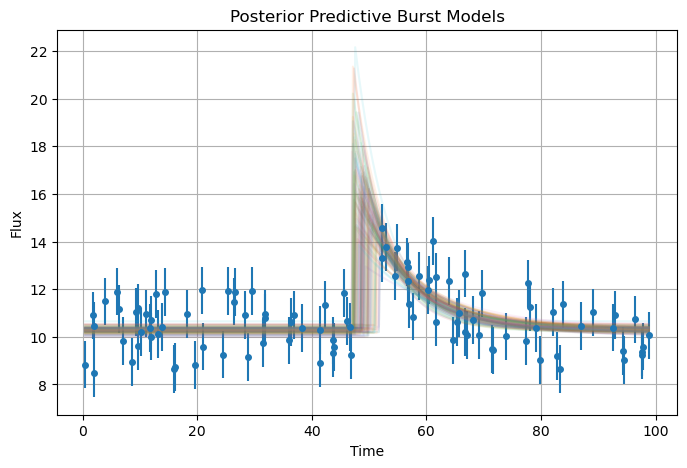

In [23]:
inds = np.random.choice(len(flat_samples), size=100, replace=False)
tt = np.linspace(time.min(), time.max(), 500)

plt.figure(figsize=(8,5))
plt.errorbar(time, flux, yerr=sigma, fmt='o', ms=4, label='Data')

for i in inds:
    b, A, t0, ln_alpha = flat_samples[i]
    alpha = np.exp(ln_alpha)

    yy = burst_model(tt, b, A, t0, alpha)
    plt.plot(tt, yy, alpha=0.1)

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Posterior Predictive Burst Models")
plt.grid(True)
plt.show()

### 7) Median and 90% intervals

In [24]:
def credible_interval(samples, name):
    q5, q50, q95 = np.percentile(samples, [5, 50, 95])
    print(f'{name} = {q50:.3f} (+{q95-q50:.3f}, -{q50-q5:.3f})')

In [25]:
credible_interval(flat_samples[:,0], 'b')
credible_interval(flat_samples[:,1], 'A')
credible_interval(flat_samples[:,2], 't0')
alpha_samples = np.exp(flat_samples[:,3])
credible_interval(alpha_samples, 'alpha')

b = 10.297 (+0.199, -0.197)
A = 5.451 (+3.407, -1.855)
t0 = 49.057 (+2.753, -1.996)
alpha = 0.123 (+0.054, -0.037)


### 8) Nested sampling

In [27]:
#!pip install dynesty

In [28]:
from dynesty import NestedSampler
from scipy.stats import uniform

In [33]:
def log_like_burst(theta):
    b, A, t0, alpha = theta
    model = burst_model(time, b, A, t0, alpha)
    return -0.5 * np.sum(((flux - model)/sigma)**2 + np.log(2*np.pi*sigma**2))

In [38]:
#Prior transform: unit cube to physical parameters (using inverse CDF = ppf)
def prior_transform_burst(u):
    ub, uA, ut0, ualpha = u

    b = uniform.ppf(ub, loc=0, scale=50)
    A = uniform.ppf(uA, loc=0, scale=50)
    t0 = uniform.ppf(ut0, loc=0, scale=100)

    ln_alpha = uniform.ppf(ualpha, loc=-5, scale=6)
    alpha = np.exp(ln_alpha)

    return np.array([b, A, t0, alpha])

In [40]:
ndim = 4
sampler_ns = NestedSampler(log_like_burst, prior_transform_burst, ndim, sample='rslice', bootstrap=0)
print('Running Nested Sampling...')
sampler_ns.run_nested(dlogz=1.0, print_progress=True)
res_burst = sampler_ns.results

samples_burst = res_burst.samples
weights = np.exp(res_burst.logwt - res_burst.logz[-1])

from dynesty.utils import resample_equal
posterior_burst = resample_equal(samples_burst, weights)
print('log(Z) burst =', res_burst.logz[-1])

Running Nested Sampling...


6971it [05:12, 22.33it/s, +500 | bound: 64 | nc: 1 | ncall: 235547 | eff(%):  3.179 | loglstar:   -inf < -140.659 <    inf | logz: -154.499 +/-  0.170 | dlogz:  0.002 >  1.000]

log(Z) burst = -154.4986644688439


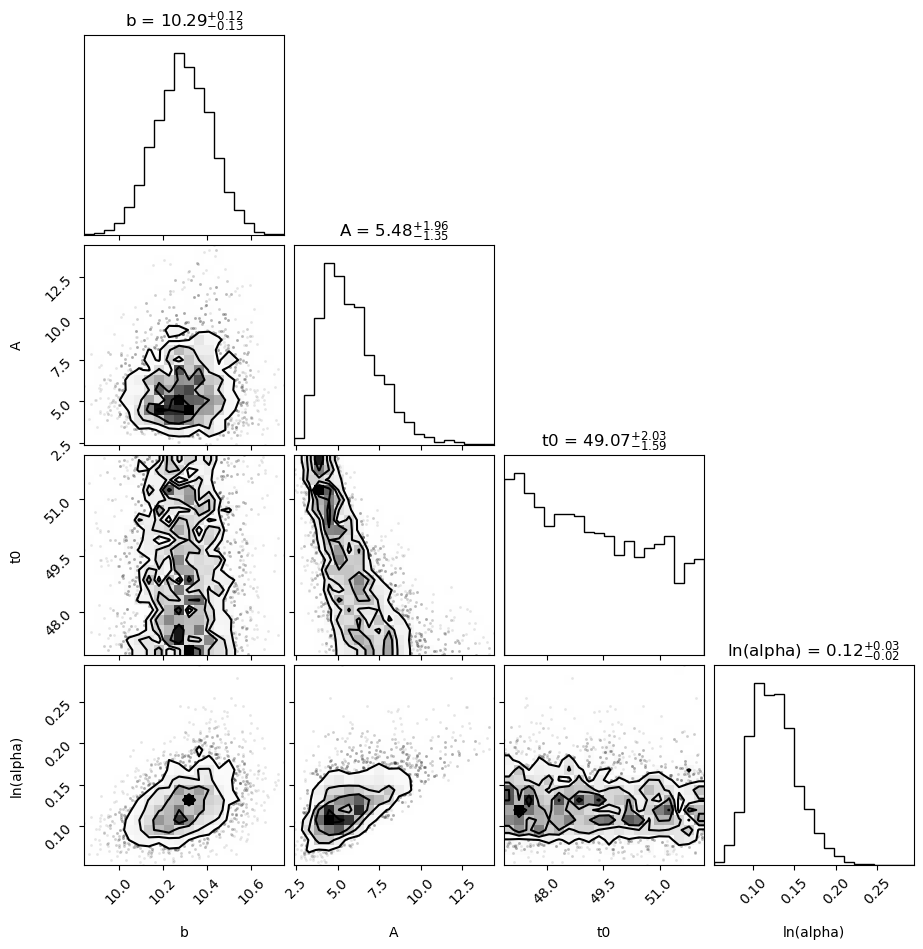

In [41]:
corner.corner(posterior_burst, labels=labels, show_titles=True)
plt.show()

### Second model: Gaussian burst

In [43]:
def gaussian_model(time, b, A, t0, w):
    return b+A*np.exp(-(time-t0)**2/(2*w**2))

In [44]:
def loglike_gauss(theta):
    b, A, t0, w = theta
    model = gaussian_model(time, b, A, t0, w)
    return -0.5*np.sum(((flux-model)/sigma)**2 + np.log(2*np.pi*sigma**2))

In [45]:
def prior_trans_gauss(u):
    ub, uA, ut0, uw = u

    b = uniform.ppf(ub, 0, 50)
    A = uniform.ppf(uA, 0, 50)
    t0 = uniform.ppf(ut0, 0, 100)
    w = uniform.ppf(uw, 1e-2, 50)

    return np.array([b, A, t0, w])

In [54]:
sampler_ns_g = NestedSampler(loglike_gauss, prior_trans_gauss, ndim, sample='rslice', bootstrap=0)
print('Running nested sampling...')
sampler_ns_g.run_nested(dlogz=1.0, print_progress=True)
res_gauss = sampler_ns_g.results
samples_gauss = res_gauss.samples
weights_g = np.exp(res_gauss.logwt - res_gauss.logz[-1])
posterior_gauss = resample_equal(samples_gauss, weights_g)
print('log(Z) gaussian =', res_gauss.logz[-1])

Running nested sampling...


8252it [06:02, 22.79it/s, +500 | bound: 74 | nc: 1 | ncall: 274844 | eff(%):  3.190 | loglstar:   -inf < -144.327 <    inf | logz: -160.809 +/-  0.189 | dlogz:  0.002 >  1.000]

log(Z) gaussian = -160.80883326556773


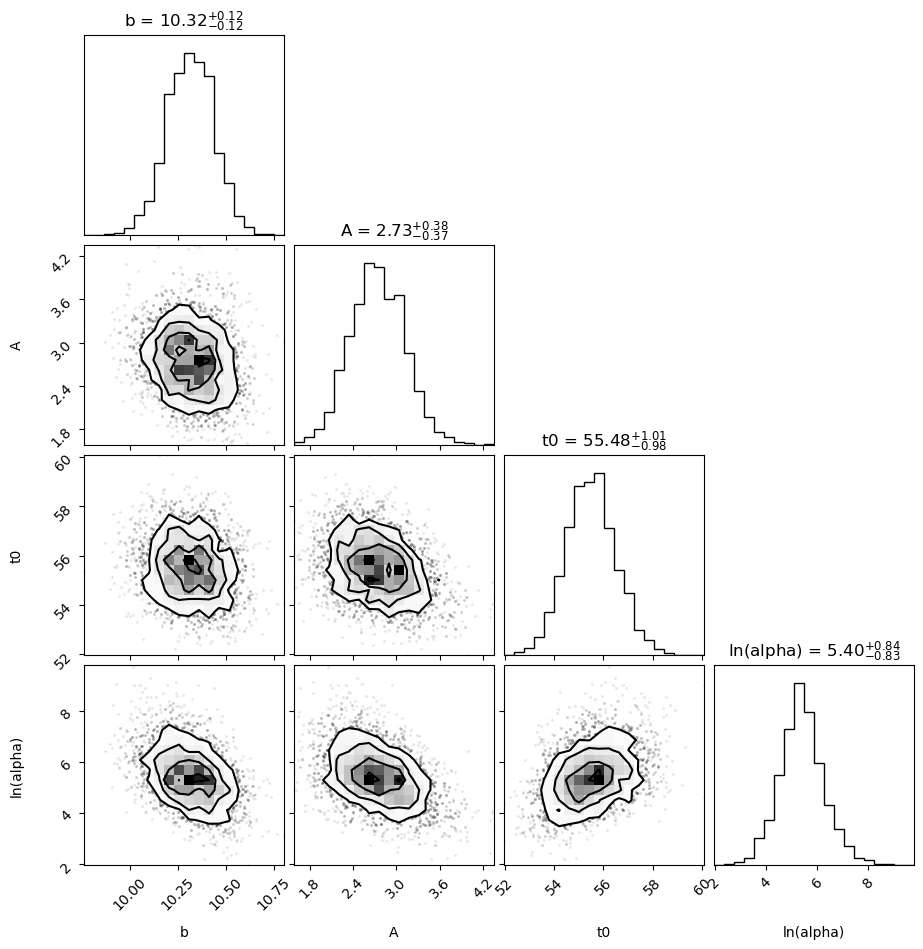

In [55]:
corner.corner(posterior_gauss, labels=labels, show_titles=True)
plt.show()

### 9) Model comparison and Jeffrey scale interpretation

In [56]:
logZ_burst = res_burst.logz[-1]
logZ_gauss = res_gauss.logz[-1]

deltalogZ = logZ_burst - logZ_gauss

print("\nModel comparison:")
print("logZ (burst)  =", logZ_burst)
print("logZ (gauss)  =", logZ_gauss)
print("ΔlogZ (burst - gauss) =", deltalogZ)


Model comparison:
logZ (burst)  = -154.4986644688439
logZ (gauss)  = -160.80883326556773
ΔlogZ (burst - gauss) = 6.310168796723815


In [57]:
def jeffreys_scale(dlogz):
    if abs(dlogz)<1:
        return 'Inconclusive'
    elif abs(dlogz)<2.5:
        return 'Weak evidence'
    elif abs(dlogz)<5:
        return 'Moderate evidence'
    else:
        return 'Strong evidence'

In [58]:
print('Interpratation:', jeffreys_scale(deltalogZ))
if deltalogZ > 0:
    print('Burst Model favored')
else:
    print('Gaussian Model favored')

Interpratation: Strong evidence
Burst Model favored
